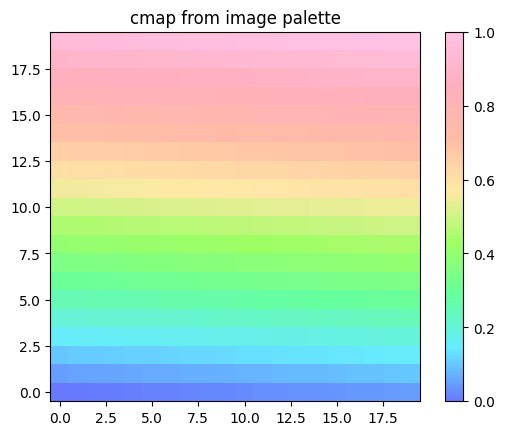

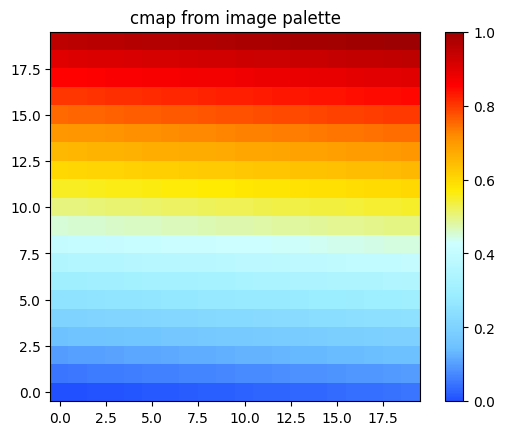

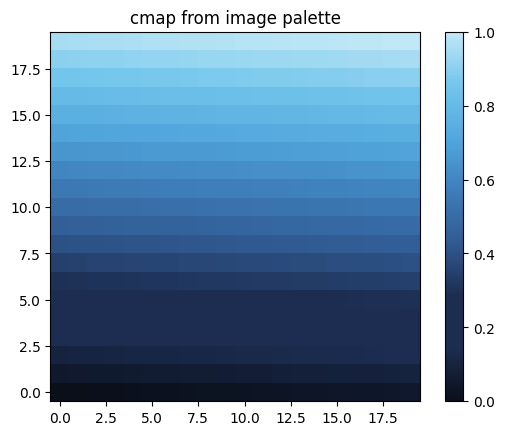

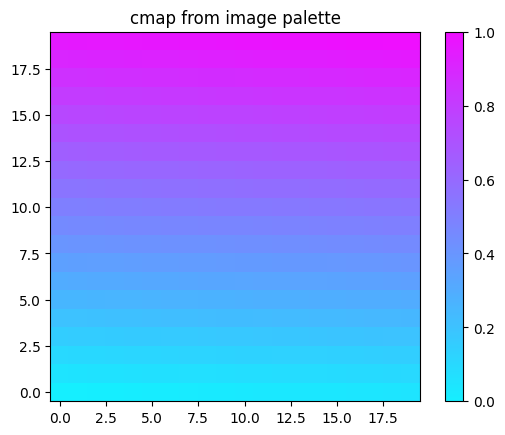

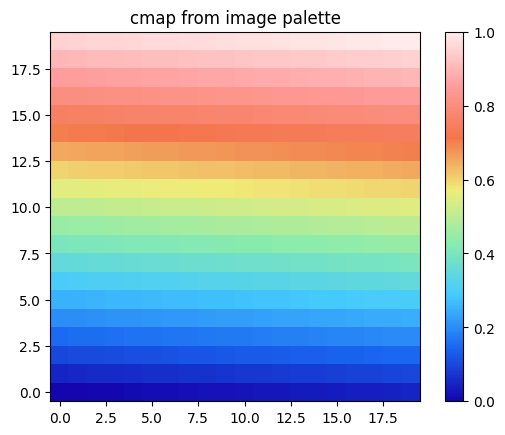

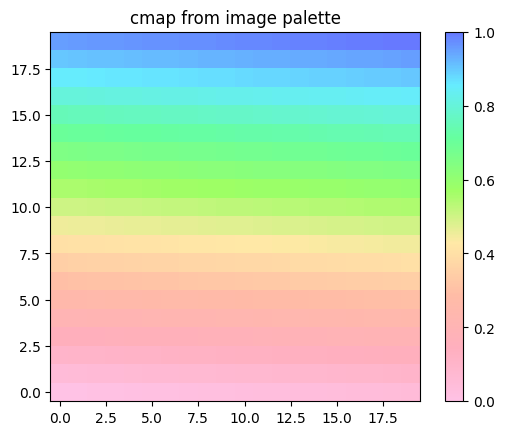

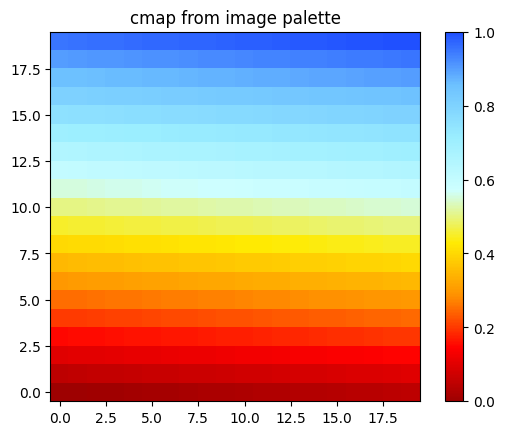

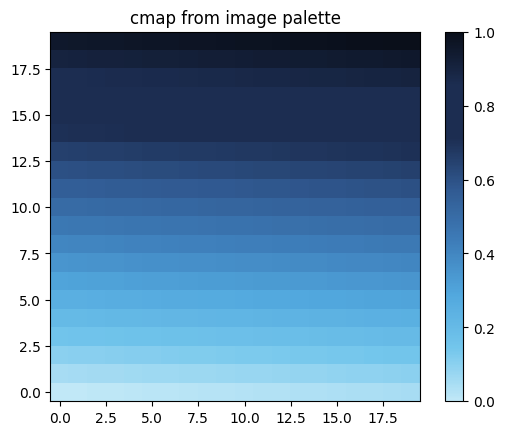

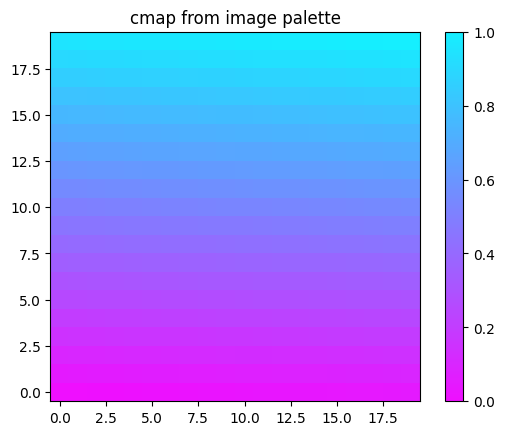

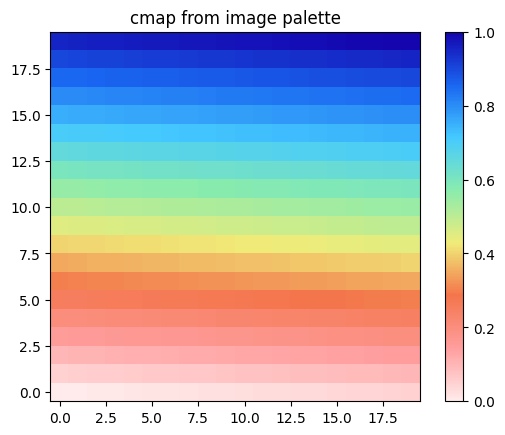

In [1]:
import numpy as np
import datetime as dt
from datetime import date
from datetime import datetime
from matplotlib import pyplot as plt
import cmocean
# from HYJfunction import *
import math
import time

from netCDF4 import Dataset
import pandas as pd
from dateutil.relativedelta import relativedelta
import matplotlib.colors
import os
import cartopy
from cartopy import crs as ccrs
import matplotlib.ticker as mticker
import matplotlib.ticker as ticker
from scipy import ndimage
from multiprocessing import Pool, Manager
import cartopy.feature as cfeature
from scipy.ndimage import convolve
from scipy.signal import detrend
import pickle
import xarray as xr
import regionmask
from matplotlib.patches import Polygon
import matplotlib.path as mpath
from matplotlib.lines import Line2D
from multiprocessing import Pool, Manager
from matplotlib.colors import BoundaryNorm, ListedColormap
import seaborn as sns
import imageio
from scipy import stats
from collections import defaultdict
from scipy.ndimage import label
from scipy.interpolate import interp2d
import sys
import os
from cartopy.util import add_cyclic_point
import gmtColors

# %% function --------------------------------
regions = ["ATL", "NP", "SP"]
seasons = ["DJF", "JJA", "ALL"]
seasonsmonths = [[12, 1, 2], [6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]]
blkTypes = ["Ridge", "Trough", "Dipole"]
cycTypes = ["CC", "AC"]
eventType = ["Blocking", "Seeding"]

def Region_ERA(regionname): 
    if regionname == "ATL": 
        lat_min, lat_max, lon_min, lon_max = 45, 75, 300, 60
    elif regionname == "NP": 
        lat_min, lat_max, lon_min, lon_max = 40, 70, 130, 250
    elif regionname == "SP": 
        lat_min, lat_max, lon_min, lon_max = -75, -45, 180, 300
    return lat_min, lat_max, lon_min, lon_max

def findClosest(lati, latids):

    if isinstance(lati, (np.ndarray, list)):  # if lat is an array or list
        closest_indices = []
        for l in lati:  
            diff = np.abs(l - latids)
            closest_idx = np.argmin(diff) 
            closest_indices.append(closest_idx)
        return closest_indices
    else:
        # if lat is a single value
        diff = np.abs(lati - latids)
        return np.argmin(diff) 

def getSectorValues(data, lat_min, lat_max, lon_min, lon_max, lat, lon):
    lat_indices = (lat >= lat_min) & (lat <= lat_max)
    lon_indices = (lon >= lon_min) & (lon <= lon_max)
    if lon_min > lon_max:
        lon_indices = (lon >= lon_min) | (lon <= lon_max)
    lat_indices = np.where(lat_indices)[0]
    lon_indices = np.where(lon_indices)[0]

    lat_indices, lon_indices = np.ix_(lat_indices, lon_indices)

    region_mask = np.zeros_like(data, dtype=bool)
    region_mask[:, lat_indices, lon_indices] = True

    data_filtered = np.where(region_mask, data, 0)

    return region_mask[0,:,:], data_filtered


In [2]:
datasets = ["ERA5", "MERRA2", "JRA3Q"]

OUT_DIR_List = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q"
}
yearnameList = {
    "ERA5": "1979_2025",
    "MERRA2": "1980_2025",
    "JRA3Q": "1979_2025"
}
timerefFile = {
    "ERA5": "/scratch/bell/hu1029/Data/processed/ERA5_Z500_6hr_1979_2025_1dg.nc",
    "MERRA2": "/scratch/bell/hu1029/Data/processed/MERRA2_Z500_6hr_1980_2025_1dg.nc",
    "JRA3Q": "/scratch/bell/hu1029/Data/processed/JRA3Q_Z500_6hr_1979_2025_1dg.nc"
}
latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lat_1979_2025_6hr.npy"
}
lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lon_1979_2025_6hr.npy"
}
TRACK_latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lat_1979_2025_6hr.npy"
}
TRACK_lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lon_1979_2025_6hr.npy"
}


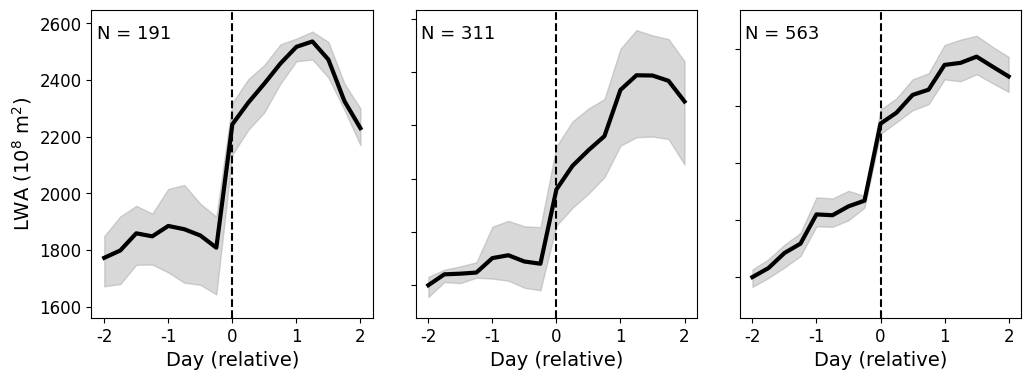

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ss = 'ALL'
typeid = 1
cyc = 'AC'

# =========================
# compute panel c data
# =========================
def compute_panel_c_data(datasets, regions, ss):

    lenbf = 8
    lenaf = 8
    relativetimestep = np.arange(-lenbf, lenaf + 1)

    type_name = {1: "Ridge", 2: "Trough", 3: "Dipole"}
    typeid = 1   # ridge only

    panel_c_data = {}

    for rgname in regions:

        dataset_series = []
        dataset_Ns = []

        for dtname in datasets:

            OUT_DIR = OUT_DIR_List[dtname]

            # ===== load =====
            if typeid == 3:
                BlkAVGLWAlist_AC = np.load(
                    f'{OUT_DIR}/{dtname}_MiddleEddiesBlkLWAseries_Type{typeid}_{rgname}_{ss}_AC_composites.npy',
                    allow_pickle=True
                )
                BlkAVGLWAlist_CC = np.load(
                    f'{OUT_DIR}/{dtname}_MiddleEddiesBlkLWAseries_Type{typeid}_{rgname}_{ss}_CC_composites.npy',
                    allow_pickle=True
                )
                BlkAVGLWAlist = np.concatenate([BlkAVGLWAlist_AC, BlkAVGLWAlist_CC], axis=0)
            else:
                cyc = 'AC' if typeid == 1 else 'CC'
                BlkAVGLWAlist = np.load(
                    f'{OUT_DIR}/{dtname}_MiddleEddiesBlkLWAseries_Type{typeid}_{rgname}_{ss}_{cyc}_composites.npy',
                    allow_pickle=True
                )

            # ===== compute =====
            BlkAVGLWAarr = np.nanmean(np.stack(BlkAVGLWAlist, axis=0), axis=0)

            dataset_series.append(BlkAVGLWAarr)
            dataset_Ns.append(len(BlkAVGLWAlist))

        dataset_series = np.array(dataset_series)

        panel_c_data[rgname] = {
            "relativetimestep": relativetimestep,
            "typeid": typeid,
            "type_name": type_name[typeid],
            "dataset_series": dataset_series,
            "mean_line": np.nanmean(dataset_series, axis=0),
            "min_line": np.nanmin(dataset_series, axis=0),
            "max_line": np.nanmax(dataset_series, axis=0),
            "Ns": dataset_Ns,
            "datasets": datasets.copy()
        }

    return panel_c_data


# =========================
# plot function
# =========================
def plot_panel_c(ax, panel_c_data, rgname, show_ylabel=True):

    data = panel_c_data[rgname]

    x = data["relativetimestep"]
    mean_line = data["mean_line"]
    min_line = data["min_line"]
    max_line = data["max_line"]
    dataset_series = data["dataset_series"]
    Ns = data["Ns"]

    ax.plot(x, mean_line, color='black', linewidth=3)
    ax.fill_between(x, min_line, max_line, color='gray', alpha=0.3)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.5)

    ax.set_ylim(np.nanmin(dataset_series) * 0.95,
                np.nanmax(dataset_series) * 1.03)

    # N label
    N_mean = int(np.round(np.mean(Ns)))
    ax.text(
        0.02, 0.95,
        f"N = {N_mean}",
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=13
    )

    # ticks
    ax.set_xticks([-8, -4, 0, 4, 8])
    ax.set_xticklabels([-2, -1, 0, 1, 2])

    ax.tick_params(axis="both", labelsize=12)

    if show_ylabel:
        ax.set_ylabel("LWA (10$^8$ m$^2$)", fontsize=14)
    else:
        ax.tick_params(labelleft=False)


# =========================
# run
# =========================
regions = ['NP', 'SP', 'ATL']

panel_c_data = compute_panel_c_data(datasets, regions, ss)

# =========================
# figure
# =========================
fig = plt.figure(figsize=(12, 4))

gs = gridspec.GridSpec(1, 3, wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

plot_panel_c(ax1, panel_c_data, 'NP', show_ylabel=True)
plot_panel_c(ax2, panel_c_data, 'SP', show_ylabel=False)
plot_panel_c(ax3, panel_c_data, 'ATL', show_ylabel=False)

for ax in [ax1, ax2, ax3]:
    ax.set_xlabel("Day (relative)", fontsize=14)

# slight alignment tweak
shift_right = 0.02
for ax in [ax1, ax2, ax3]:
    pos = ax.get_position()
    ax.set_position([pos.x0 + shift_right, pos.y0, pos.width, pos.height])

# # save
# plt.savefig(
#     './FINAL_figures/panel_c_only.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

In [4]:
# =========================
# compute panel c data（加 typeid, cyc）
# =========================
def compute_panel_c_data(datasets, regions, ss, typeid, cyc):

    lenbf = 8
    lenaf = 8
    relativetimestep = np.arange(-lenbf, lenaf + 1)

    type_name = {1: "Ridge", 2: "Trough", 3: "Dipole"}

    panel_c_data = {}

    for rgname in regions:

        dataset_series = []
        dataset_Ns = []

        for dtname in datasets:

            OUT_DIR = OUT_DIR_List[dtname]

            # ===== load =====
            if typeid == 3:
                BlkAVGLWAlist_AC = np.load(
                    f'{OUT_DIR}/{dtname}_MiddleEddiesBlkLWAseries_Type{typeid}_{rgname}_{ss}_AC_composites.npy',
                    allow_pickle=True
                )
                BlkAVGLWAlist_CC = np.load(
                    f'{OUT_DIR}/{dtname}_MiddleEddiesBlkLWAseries_Type{typeid}_{rgname}_{ss}_CC_composites.npy',
                    allow_pickle=True
                )
                BlkAVGLWAlist = BlkAVGLWAlist_AC if cyc == 'AC' else BlkAVGLWAlist_CC
            else:
                BlkAVGLWAlist = np.load(
                    f'{OUT_DIR}/{dtname}_MiddleEddiesBlkLWAseries_Type{typeid}_{rgname}_{ss}_{cyc}_composites.npy',
                    allow_pickle=True
                )

            # ===== compute =====
            BlkAVGLWAarr = np.nanmean(np.stack(BlkAVGLWAlist, axis=0), axis=0)

            dataset_series.append(BlkAVGLWAarr)
            dataset_Ns.append(len(BlkAVGLWAlist))

        dataset_series = np.array(dataset_series)

        panel_c_data[rgname] = {
            "relativetimestep": relativetimestep,
            "type_name": type_name[typeid],
            "dataset_series": dataset_series,
            "mean_line": np.nanmean(dataset_series, axis=0),
            "min_line": np.nanmin(dataset_series, axis=0),
            "max_line": np.nanmax(dataset_series, axis=0),
            "Ns": dataset_Ns,
        }

    return panel_c_data

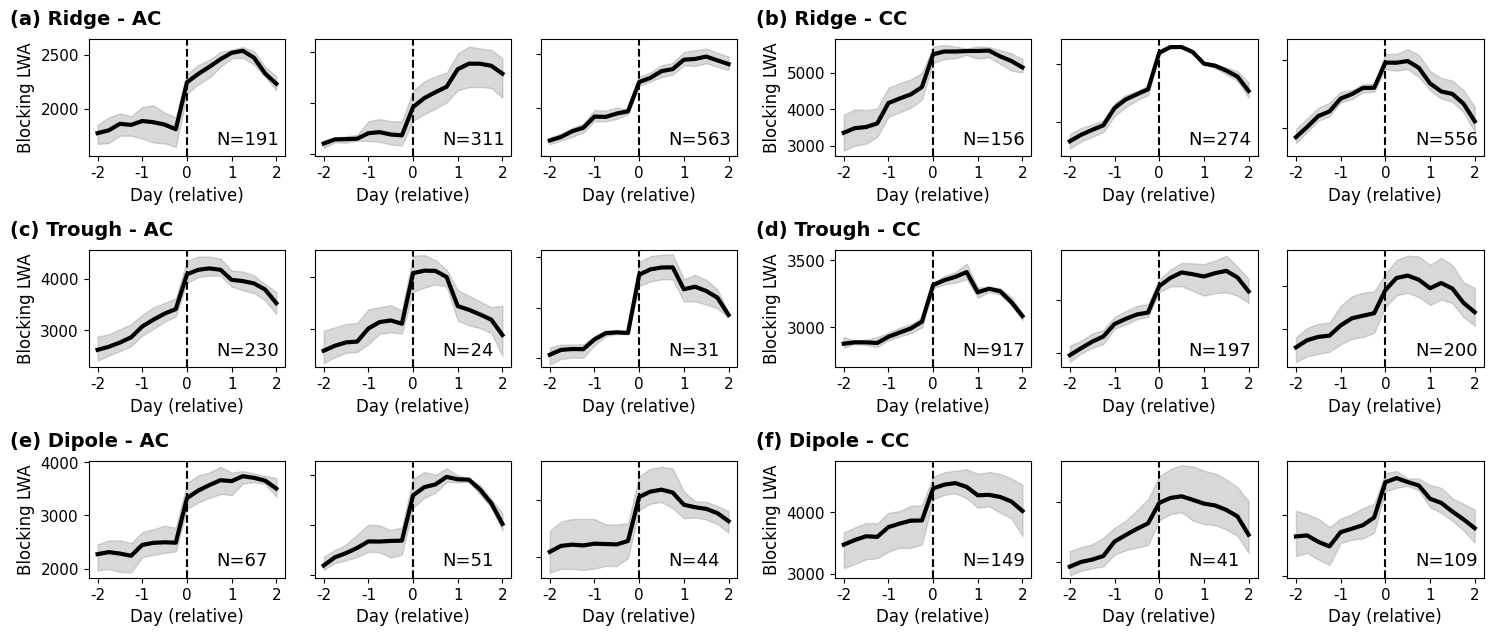

In [35]:
def plot_panel_c(ax, panel_c_data, rgname, show_ylabel=True):

    data = panel_c_data[rgname]

    x = data["relativetimestep"]
    mean_line = data["mean_line"]
    min_line = data["min_line"]
    max_line = data["max_line"]
    dataset_series = data["dataset_series"]
    Ns = data["Ns"]

    ax.plot(x, mean_line, color='black', linewidth=3)
    ax.fill_between(x, min_line, max_line, color='gray', alpha=0.3)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.5)

    ax.set_ylim(np.nanmin(dataset_series) * 0.95,
                np.nanmax(dataset_series) * 1.03)

    # N label
    N_mean = int(np.round(np.mean(Ns)))
    ax.text(
        0.65, 0.1,
        f"N={N_mean}",
        transform=ax.transAxes,
        fontsize=13
    )

    # ticks
    ax.set_xticks([-8, -4, 0, 4, 8])
    ax.set_xticklabels([-2, -1, 0, 1, 2])

    ax.tick_params(axis="both", labelsize=11)

    if show_ylabel:
        ax.set_ylabel("Blocking LWA", fontsize=12)
    else:
        ax.tick_params(labelleft=False)


regions = ['NP', 'SP', 'ATL']
type_list = [1, 2, 3]
cyc_list = ['AC', 'CC']

fig = plt.figure(figsize=(18, 7))

outer = gridspec.GridSpec(
    nrows=3, ncols=2,
    hspace=0.8, wspace=0.15
)

labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for i, typeid in enumerate(type_list):
    for j, cyc in enumerate(cyc_list):

        panel_c_data = compute_panel_c_data(datasets, regions, ss, typeid, cyc)

        inner = gridspec.GridSpecFromSubplotSpec(
            1, 3,
            subplot_spec=outer[i, j],
            wspace=0.15
        )

        ax1 = fig.add_subplot(inner[0, 0])
        ax2 = fig.add_subplot(inner[0, 1])
        ax3 = fig.add_subplot(inner[0, 2])

        plot_panel_c(ax1, panel_c_data, 'NP', show_ylabel=True)
        plot_panel_c(ax2, panel_c_data, 'SP', show_ylabel=False)
        plot_panel_c(ax3, panel_c_data, 'ATL', show_ylabel=False)

        for ax in [ax1, ax2, ax3]:
            ax.set_xlabel("Day (relative)", fontsize=12)

        idx = i * 2 + j
        ax1.set_title(f"{labels[idx]} {['Ridge','Trough','Dipole'][i]} - {cyc}", fontsize=14, x=-0.4,y=1.05,
        loc='left', fontweight="bold")
        

plt.savefig(
    './FINAL_figures/Nature_ExtendedFig3.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()